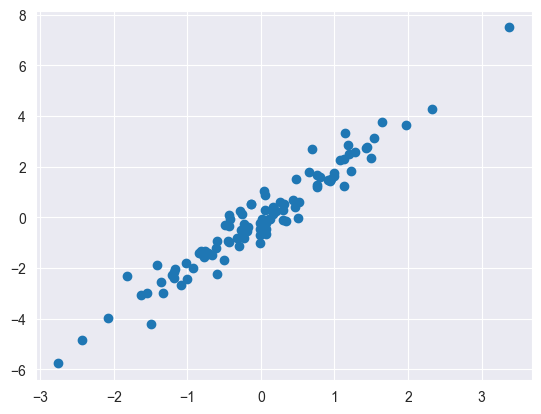

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

n_samples = 100

x = np.random.normal(0, 1, n_samples)
y = 2 * x + np.random.normal(0, 0.5, n_samples)

X = np.column_stack((x, y))

plt.scatter(X[:, 0], X[:, 1])

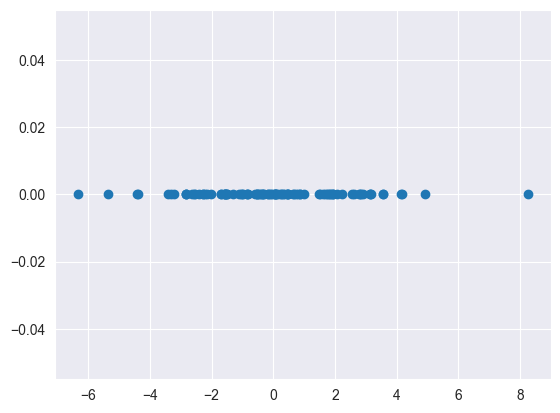

Главная компонента: [[0.43690521 0.89950755]]
Объяснение дисперсии: [0.99000134]


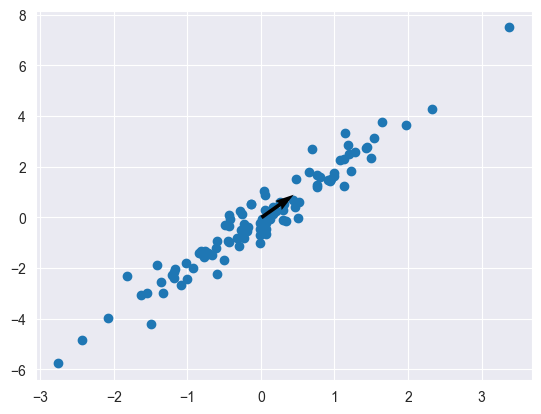

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], np.zeros_like(X_pca))
plt.show()

print(f'Главная компонента: {pca.components_}')
print(f'Объяснение дисперсии: {pca.explained_variance_ratio_}')

plt.scatter(X[:, 0], X[:, 1])
direction_pc1 = pca.components_[0]
plt.quiver(0, 0, direction_pc1[0], direction_pc1[1], angles='xy', scale_units='xy', scale=1)
plt.show()

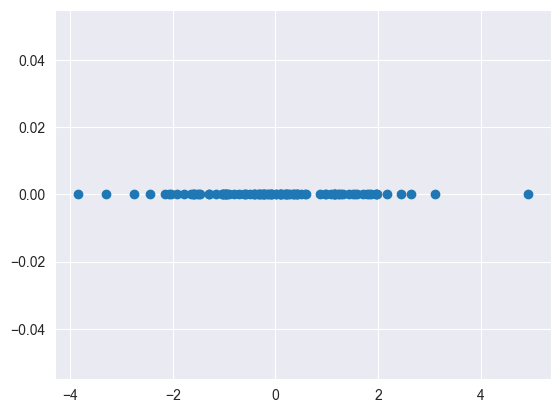

Главная компонента: [[0.43690521 0.89950755]]
Объяснение дисперсии: [0.99000134]


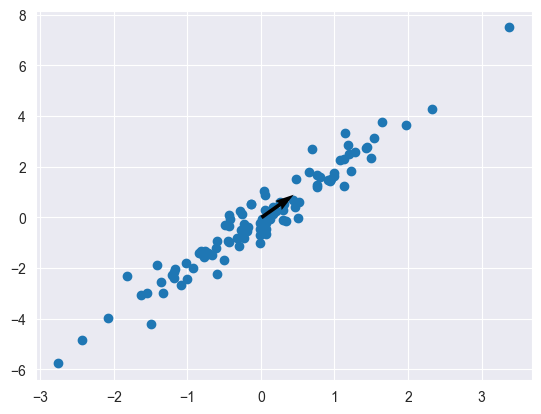

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=1)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

plt.scatter(X_pca_scaled[:, 0],  np.zeros_like(X_pca))
plt.show()

print(f'Главная компонента: {pca.components_}')
print(f'Объяснение дисперсии: {pca.explained_variance_ratio_}')

plt.scatter(X[:, 0], X[:, 1])
direction_pc1 = pca.components_[0]
plt.quiver(0, 0, direction_pc1[0], direction_pc1[1], angles='xy', scale_units='xy', scale=1)
plt.show()

Главная компонента: [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]
Объяснение дисперсии: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


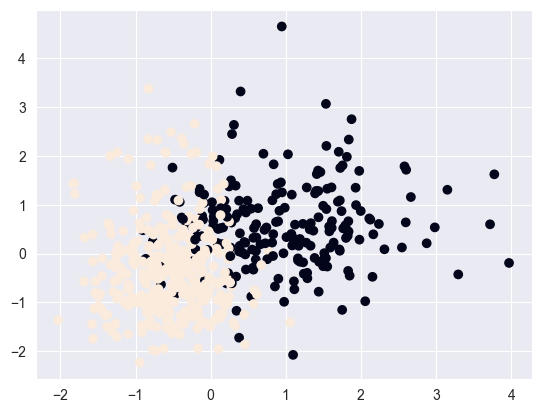

In [5]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Главная компонента: {pca.components_}')
print(f'Объяснение дисперсии: {pca.explained_variance_ratio_}')
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.2f}")

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.show()

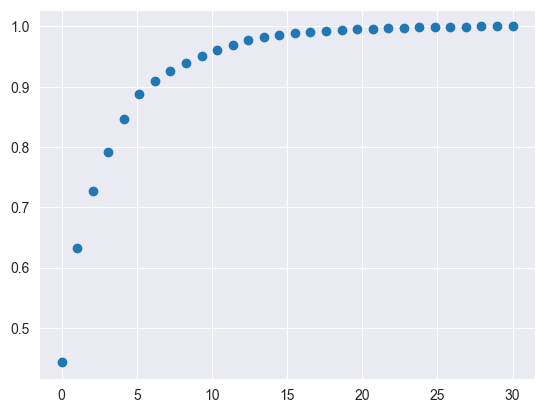

Объяснение дисперсии: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


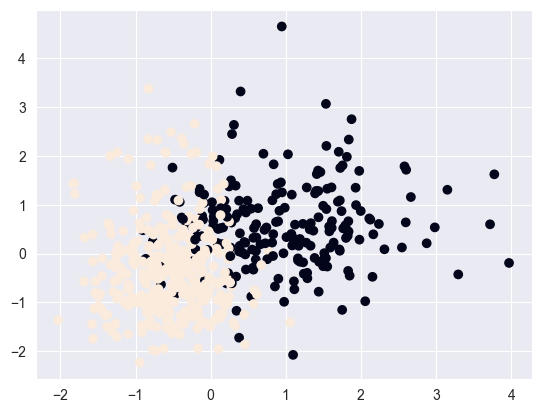

In [6]:
explained_variance = []

for n in range(1, 31):
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

plt.scatter(np.linspace(0, len(explained_variance), len(explained_variance)), explained_variance,)
plt.show()

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

print(f'Объяснение дисперсии: {pca.explained_variance_ratio_}')
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.2f}")

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.show()

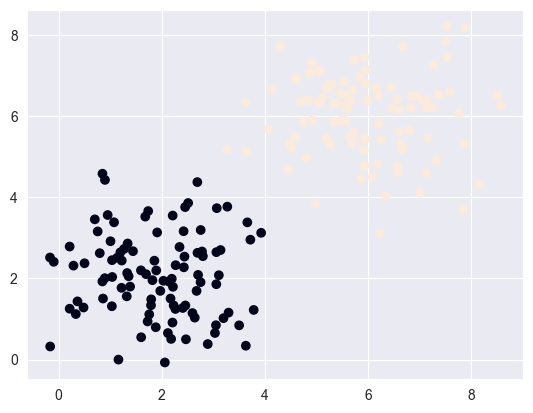

In [7]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()


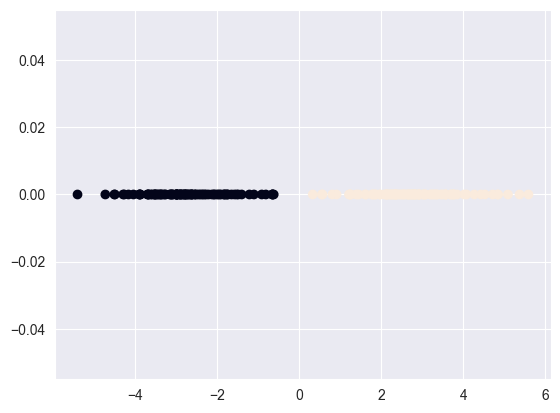

Коэффициенты LDA [[8.62638725 8.52928926]]


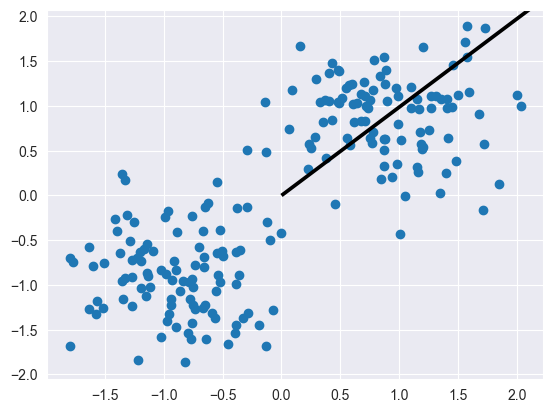

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.scatter(X_lda[:, 0], np.zeros_like(X_lda), c=y)
plt.show()

print(f'Коэффициенты LDA {lda.coef_}')

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
direction_lda1 = lda.coef_[0]
plt.quiver(0, 0, direction_lda1[0], direction_lda1[1], angles='xy', scale_units='xy', scale=1)
plt.show()

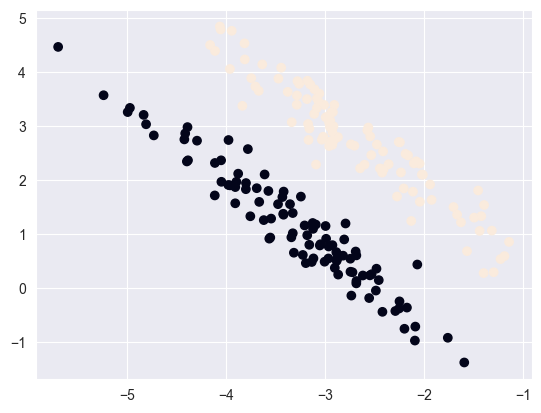

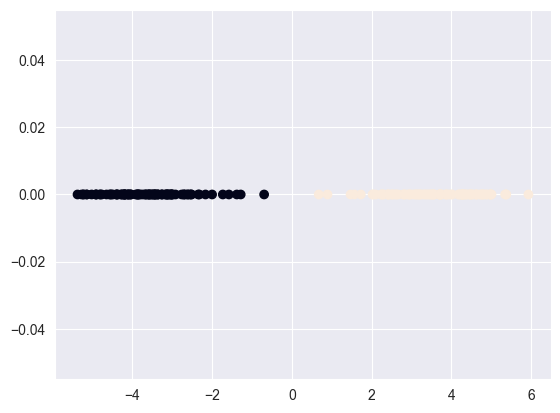

Коэффициенты LDA [[24.59931105 28.80353457]]


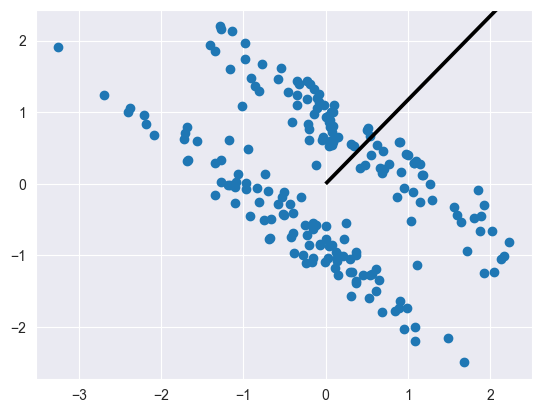

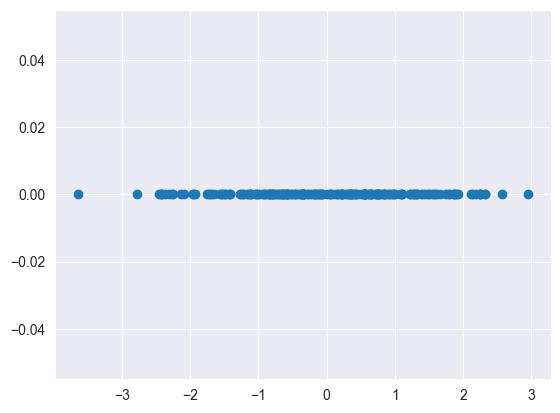

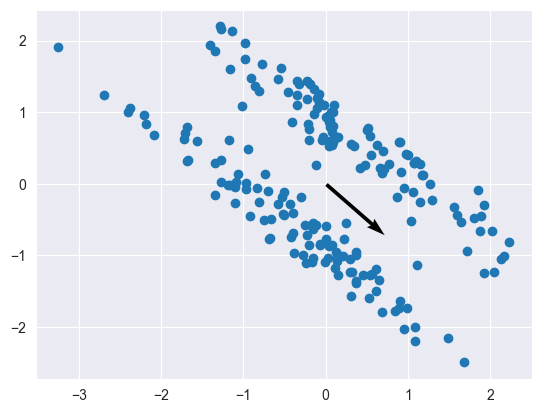

In [9]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.scatter(X_lda[:, 0], np.zeros_like(X_lda), c=y)
plt.show()

print(f'Коэффициенты LDA {lda.coef_}')

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
direction_lda1 = lda.coef_[0]
plt.quiver(0, 0, direction_lda1[0], direction_lda1[1], angles='xy', scale_units='xy', scale=1)
plt.show()

pca_scaled = PCA(n_components=1)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

plt.scatter(X_pca_scaled[:, 0],  np.zeros_like(X_pca_scaled))
plt.show()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
direction_pc1 = pca_scaled.components_[0]
plt.quiver(0, 0, direction_pc1[0], direction_pc1[1], angles='xy', scale_units='xy', scale=1)
plt.show()

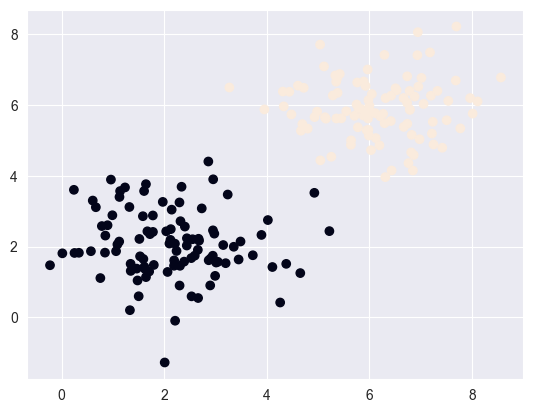

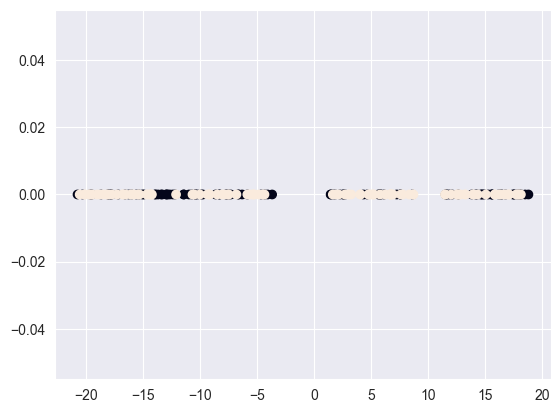

In [10]:
from sklearn.manifold import TSNE

n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], np.zeros_like(X_tsne), c=y)
plt.show()


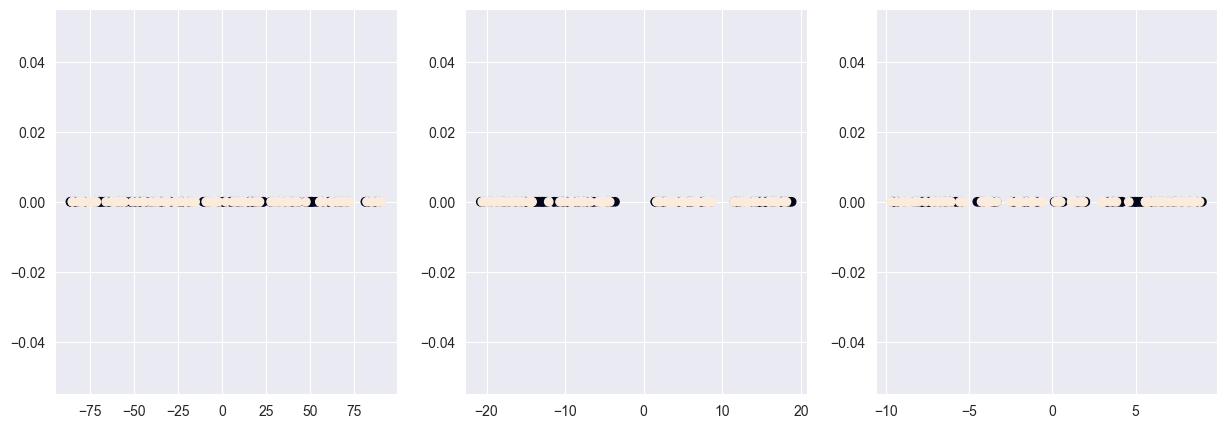

In [11]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))

for i, perplexity_value in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity_value, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne[:, 0], np.zeros_like(X_tsne), c=y)
plt.show()

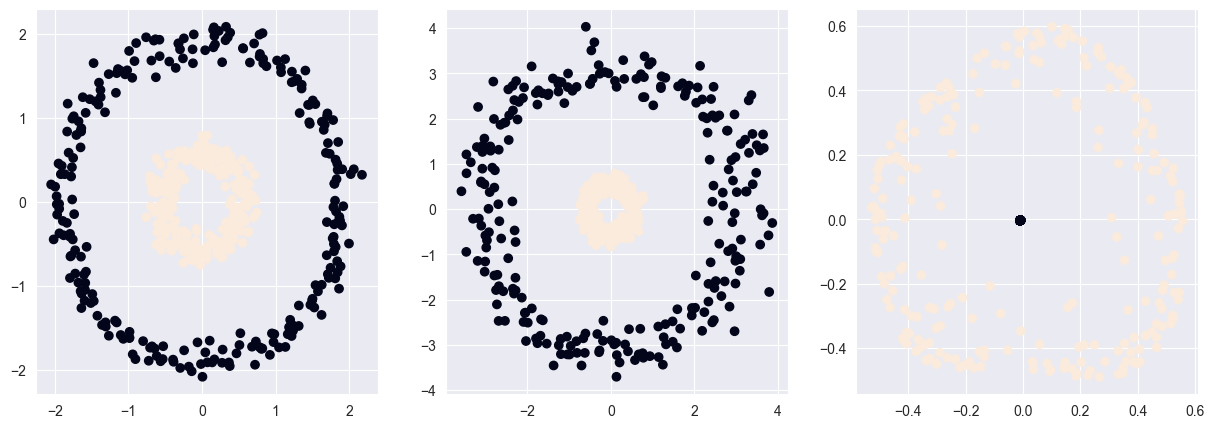

In [12]:
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA

X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(15, 5))

kernels = ['linear', 'poly', 'rbf']

for n, kernel in enumerate(kernels):
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=10 if kernel == 'rbf' else None)
    X_kpca = kpca.fit_transform(X_scaled)
    plt.subplot(1, 3, n+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.show()

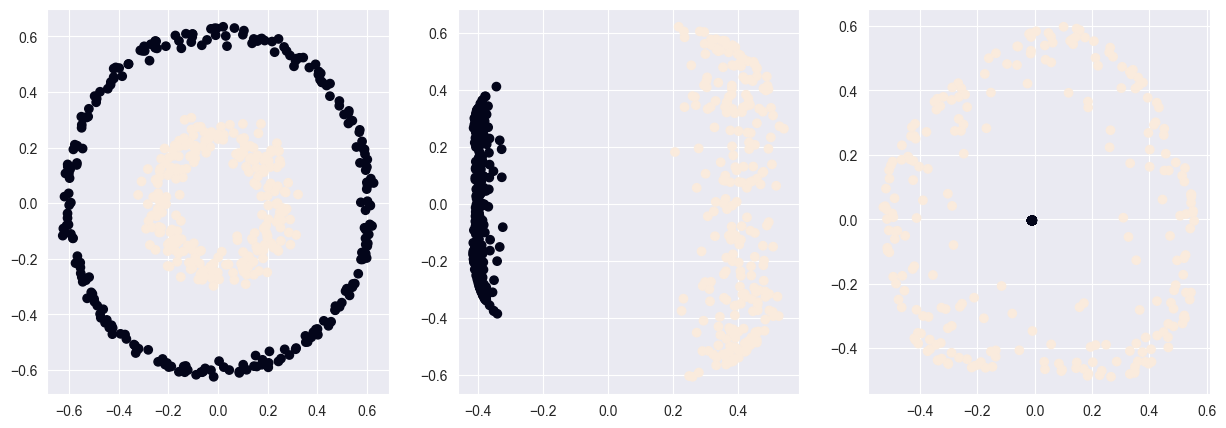

In [13]:
gamma_values = [0.1, 1, 10]
plt.figure(figsize=(15, 5))

for n, gamma in enumerate(gamma_values):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    X_kpca = kpca.fit_transform(X_scaled)
    plt.subplot(1, 3, n+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.show()

Главная компонента: [[0.40425991 0.91464415]]
Объяснение дисперсии: [0.94425349]


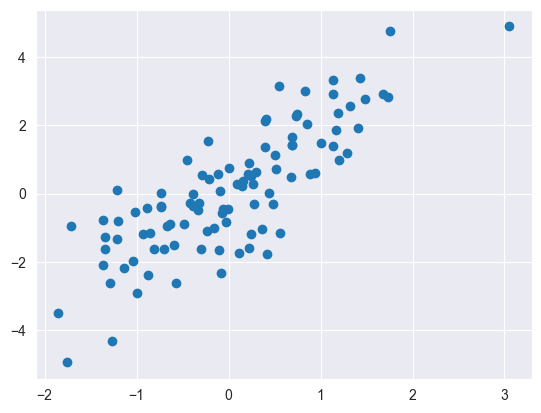

In [35]:
n_samples = 100

x = np.random.normal(0, 1, n_samples)
y = 2 * x + np.random.normal(0, 1, n_samples)

X = np.column_stack((x, y))

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

print(f'Главная компонента: {pca.components_}')
print(f'Объяснение дисперсии: {pca.explained_variance_ratio_}')

plt.scatter(X[:, 0], X[:, 1])
plt.show()

Главная компонента: [[ 0.39549283  0.91675121  0.05614834]
 [-0.42100928  0.12661567  0.89817574]]
Объяснение дисперсии: 0.9883606218928125


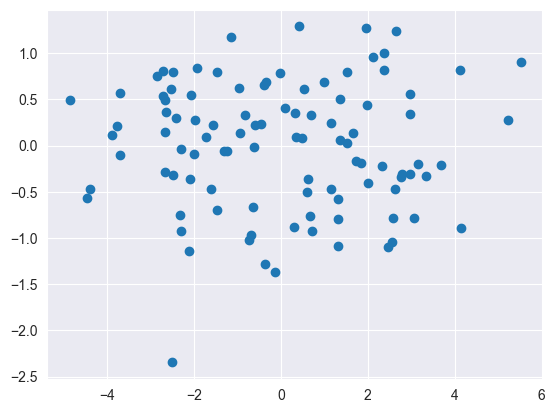

In [37]:
n_samples = 100

x = np.random.normal(0, 1, n_samples)
y = 2 * x + np.random.normal(0, 1, n_samples)
z = -x + 0.5 * y + np.random.normal(0, 0.5, n_samples)

X = np.column_stack((x, y, z))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f'Главная компонента: {pca.components_}')
print(f'Объяснение дисперсии: {sum(pca.explained_variance_ratio_)}')

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.show()

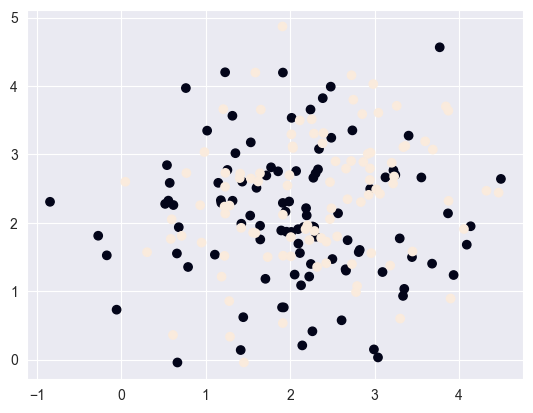

Главная компонента: [[0.19796611 0.29721582]]
Объяснение дисперсии: 1.0


In [50]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(2.3, 1, n_samples)
y2 = np.random.normal(2.3, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

print(f'Главная компонента: {lda.coef_}')
print(f'Объяснение дисперсии: {sum(lda.explained_variance_ratio_)}')


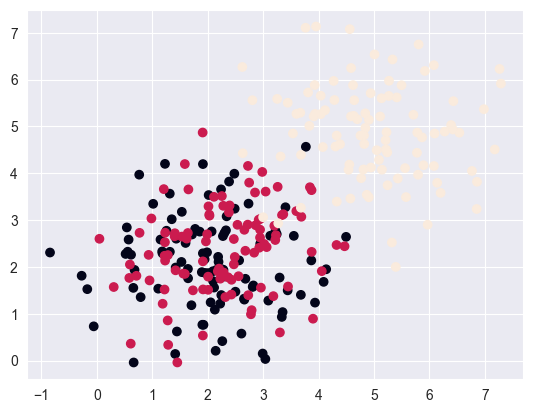

LDA
Главная компонента: [[-1.65627478 -1.63024689 -0.29519078]
 [-1.30757224 -1.14489961 -0.29871296]
 [ 2.96384702  2.77514649  0.59390374]]
Объяснение дисперсии: 1.0000000000000002
PCA
Главная компонента: [[ 0.70301381  0.6491928   0.29037955]
 [ 0.68904519 -0.52070429 -0.50406722]]
Объяснение дисперсии: 0.8603711242649564


In [56]:
z1 = np.random.normal(4, 1, n_samples)
z2 = np.random.normal(4, 1, n_samples)
x3 = np.random.normal(5, 1, n_samples)
y3 = np.random.normal(5, 1, n_samples)
z3 = np.random.normal(5, 1, n_samples)

X = np.vstack((
    np.column_stack((x1, y1, z1)),
    np.column_stack((x2, y2, z2)),
    np.column_stack((x3, y3, z3))
))

y = np.hstack((
    np.zeros(n_samples),
    np.ones(n_samples),
    np.full(n_samples, 2)
))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print('LDA')
print(f'Главная компонента: {lda.coef_}')
print(f'Объяснение дисперсии: {sum(lda.explained_variance_ratio_)}')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print('PCA')
print(f'Главная компонента: {pca.components_}')
print(f'Объяснение дисперсии: {sum(pca.explained_variance_ratio_)}')


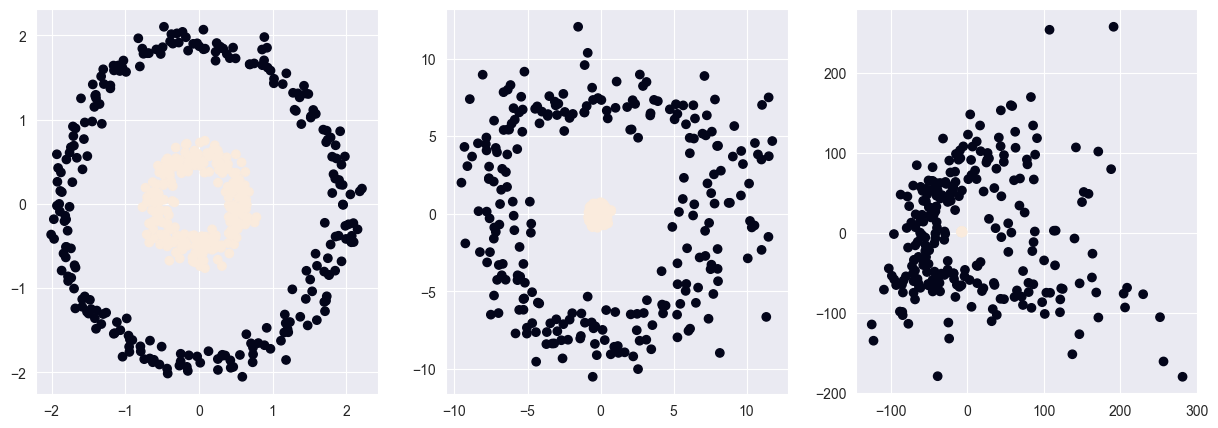

In [59]:
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

degree_values = [2, 5, 10]
plt.figure(figsize=(15, 5))

for n, degree in enumerate(degree_values):
    kpca = KernelPCA(n_components=2, kernel='poly', degree=degree)
    X_kpca = kpca.fit_transform(X_scaled)
    plt.subplot(1, 3, n+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.show()

LDA
Главная компонента: [[  5.21157831   5.27345252 -29.81560843 -15.77885735]
 [ -1.26370067  -1.90100128   8.26157263   2.32662354]
 [ -3.94787765  -3.37245124  21.5540358   13.45223381]]
Объяснение дисперсии: 1.0
PCA
Главная компонента: [[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]]
Объяснение дисперсии: 0.977685206318796
TSNE


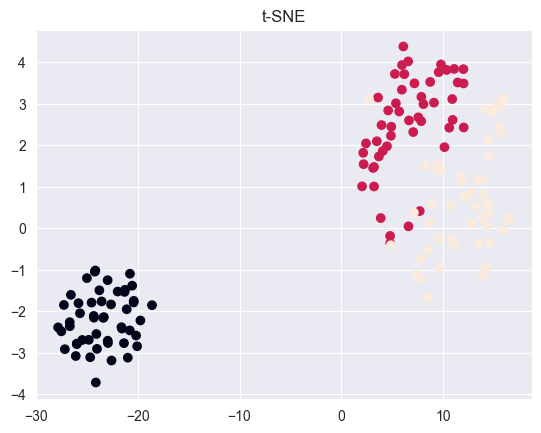

In [65]:
from sklearn.datasets import load_iris

iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

X = data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print('LDA')
print(f'Главная компонента: {lda.coef_}')
print(f'Объяснение дисперсии: {sum(lda.explained_variance_ratio_)}')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print('PCA')
print(f'Главная компонента: {pca.components_}')
print(f'Объяснение дисперсии: {sum(pca.explained_variance_ratio_)}')

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print('TSNE')
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
plt.title('t-SNE')
plt.show()

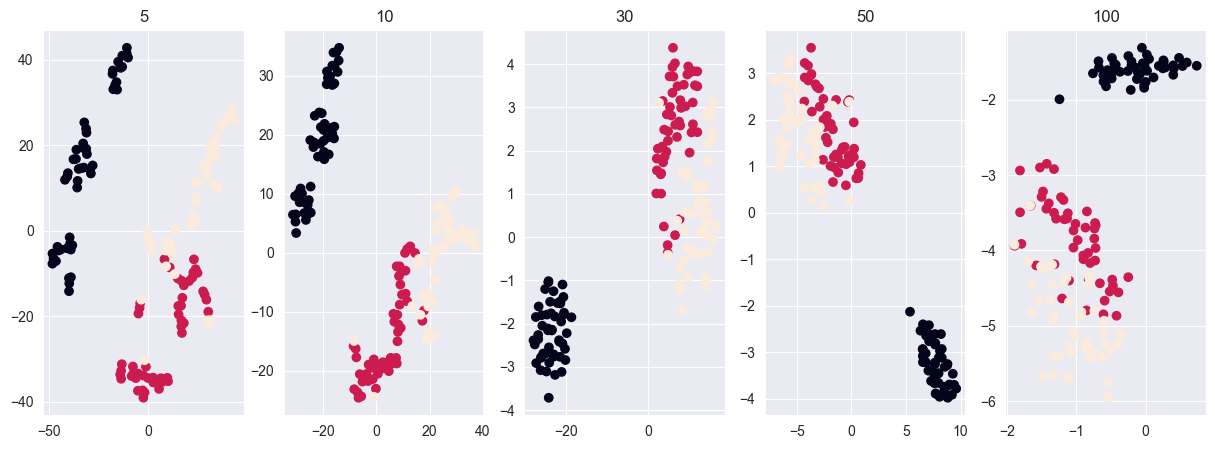

In [66]:
perplexities = [5, 10, 30, 50, 100]

fig, ax = plt.subplots(1, len(perplexities), figsize=(15, 5))

for n, perplexity in enumerate(perplexities):
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    X_tsne = tsne.fit_transform(X_scaled)
    ax[n].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
    ax[n].set_title(perplexity)

plt.show()

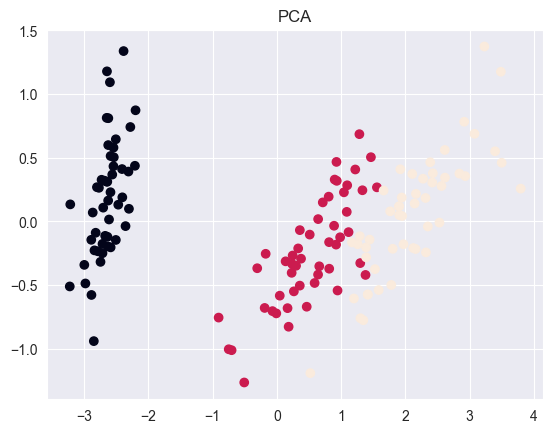

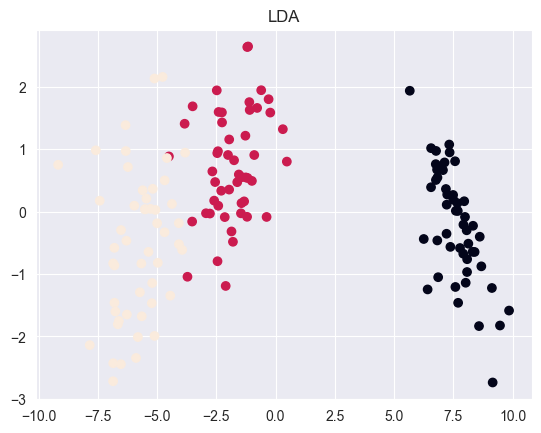

In [68]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title('PCA')
plt.show()
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y)
plt.title('LDA')
plt.show()

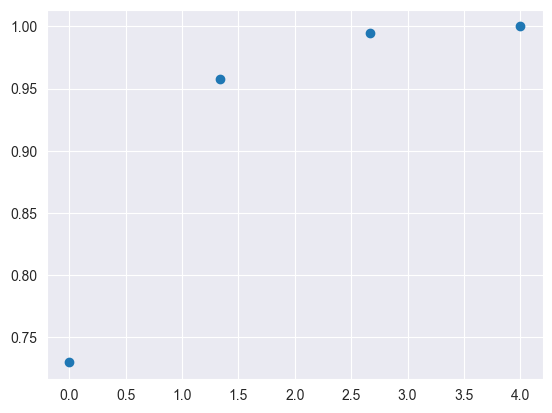

Объяснение дисперсии: [0.72962445 0.22850762]
Суммарная объясненная дисперсия: 0.96


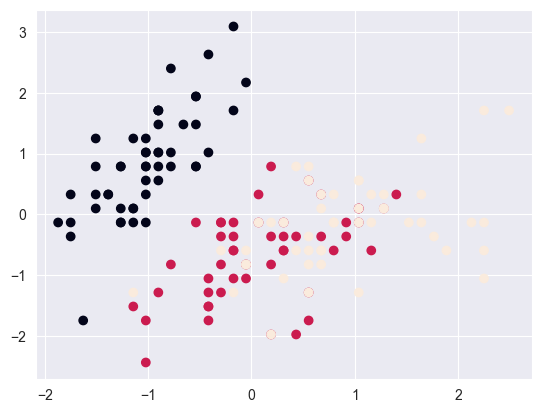

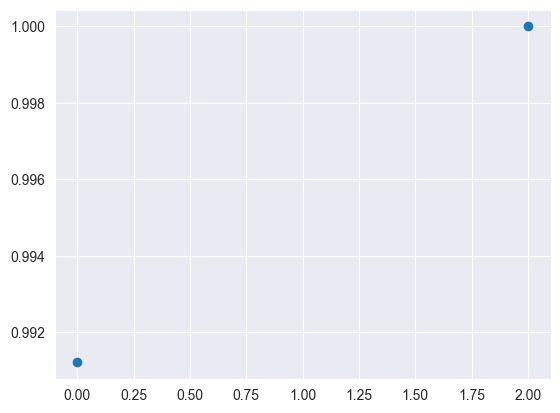

Объяснение дисперсии: [0.9912126 0.0087874]
Суммарная объясненная дисперсия: 1.00


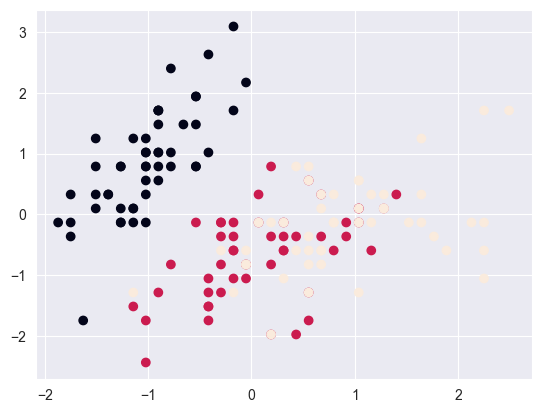

In [78]:
explained_variance = []

for n in range(1, 5):
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

plt.scatter(np.linspace(0, len(explained_variance), len(explained_variance)), explained_variance,)
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Объяснение дисперсии: {pca.explained_variance_ratio_}')
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.2f}")

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.show()

explained_variance = []
max_components = min(X_scaled.shape[1], len(np.unique(y)) - 1)

for n in range(1, max_components + 1):
    lda = LDA(n_components=n)
    lda.fit(X_scaled, y)
    explained_variance.append(sum(lda.explained_variance_ratio_))

plt.scatter(np.linspace(0, len(explained_variance), len(explained_variance)), explained_variance,)
plt.show()

lda = LDA(n_components=2)
X_pca = lda.fit_transform(X_scaled, y)

print(f'Объяснение дисперсии: {lda.explained_variance_ratio_}')
print(f"Суммарная объясненная дисперсия: {sum(lda.explained_variance_ratio_):.2f}")

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.show()

In [84]:
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

print(f'Объяснение дисперсии: {pca.explained_variance_ratio_}')
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.2f}")

test_var = pca.transform(X_test)

test_variance_ratio = np.var(pca.transform(X_test), axis=0).sum() / np.var(X_test, axis=0).sum()
print(test_variance_ratio)

lda = LDA(n_components=2)
X_pca = lda.fit_transform(X_train, y_train)

print(f'Объяснение дисперсии: {lda.explained_variance_ratio_}')
print(f"Суммарная объясненная дисперсия: {sum(lda.explained_variance_ratio_):.2f}")

test_var = lda.transform(X_test)

y_pred = lda.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Объяснение дисперсии: [0.71537436 0.24083209]
Суммарная объясненная дисперсия: 0.96
0.9670770963575147
Объяснение дисперсии: [0.99229795 0.00770205]
Суммарная объясненная дисперсия: 1.00
Accuracy: 1.0
